# Camera Votazioni 2018-2025 — validazione dati

Notebook tecnico. Genera le figure per il README.

**Dataset**: `camera_votazioni_sparql` (Camera dei Deputati) via GCS clean parquet.
**Serie**: 2018-2025, 26.840 votazioni.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.options.display.float_format = '{:,.1f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')

GCS = 'gs://dataciviclab-clean/camera_votazioni_sparql/*/camera_votazioni_sparql_*_clean.parquet'

cnt = con.execute(f"SELECT count(*) FROM read_parquet('{GCS}')").fetchone()[0]
print(f"Votazioni totali: {cnt:,}")
anni = con.execute(f"SELECT DISTINCT YEAR(data) as anno FROM read_parquet('{GCS}') ORDER BY 1").fetchdf()
print(f"Anni: {list(anni['anno'])}")

Votazioni totali: 26,840


Anni: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [2]:
# 1. Trend votazioni e partecipazione
trend = con.execute(f"""
    SELECT YEAR(data) as anno,
           COUNT(*) as votazioni,
           ROUND(AVG(presenti)) as media_presenti,
           ROUND(AVG(votanti)) as media_votanti,
           ROUND(AVG(favorevoli)) as media_fav,
           ROUND(AVG(contrari)) as media_cont
    FROM read_parquet('{GCS}')
    GROUP BY 1 ORDER BY 1
""").fetchdf()
display(trend)

v18 = trend[trend['anno']==2018]['media_votanti'].values[0]
v25 = trend[trend['anno']==2025]['media_votanti'].values[0]
print(f"Media votanti: {v18:.0f} (2018) -> {v25:.0f} (2025) = -{(1-v25/v18)*100:.0f}%")
print(f"Votazioni annue: {int(trend[trend['anno']==2018]['votazioni'].values[0]):,} -> {int(trend[trend['anno']==2025]['votazioni'].values[0]):,}")

,anno,votazioni,media_presenti,media_votanti,media_fav,media_cont
0,2018,2144,486.0,455.0,198.0,257.0
1,2019,2484,453.0,428.0,224.0,203.0
2,2020,2166,440.0,429.0,228.0,201.0
3,2021,2325,409.0,396.0,155.0,241.0
4,2022,2121,372.0,360.0,148.0,212.0
5,2023,4661,276.0,262.0,138.0,125.0
6,2024,5903,265.0,253.0,130.0,123.0
7,2025,5036,254.0,244.0,113.0,131.0


Media votanti: 455 (2018) -> 244 (2025) = -46%
Votazioni annue: 2,144 -> 5,036


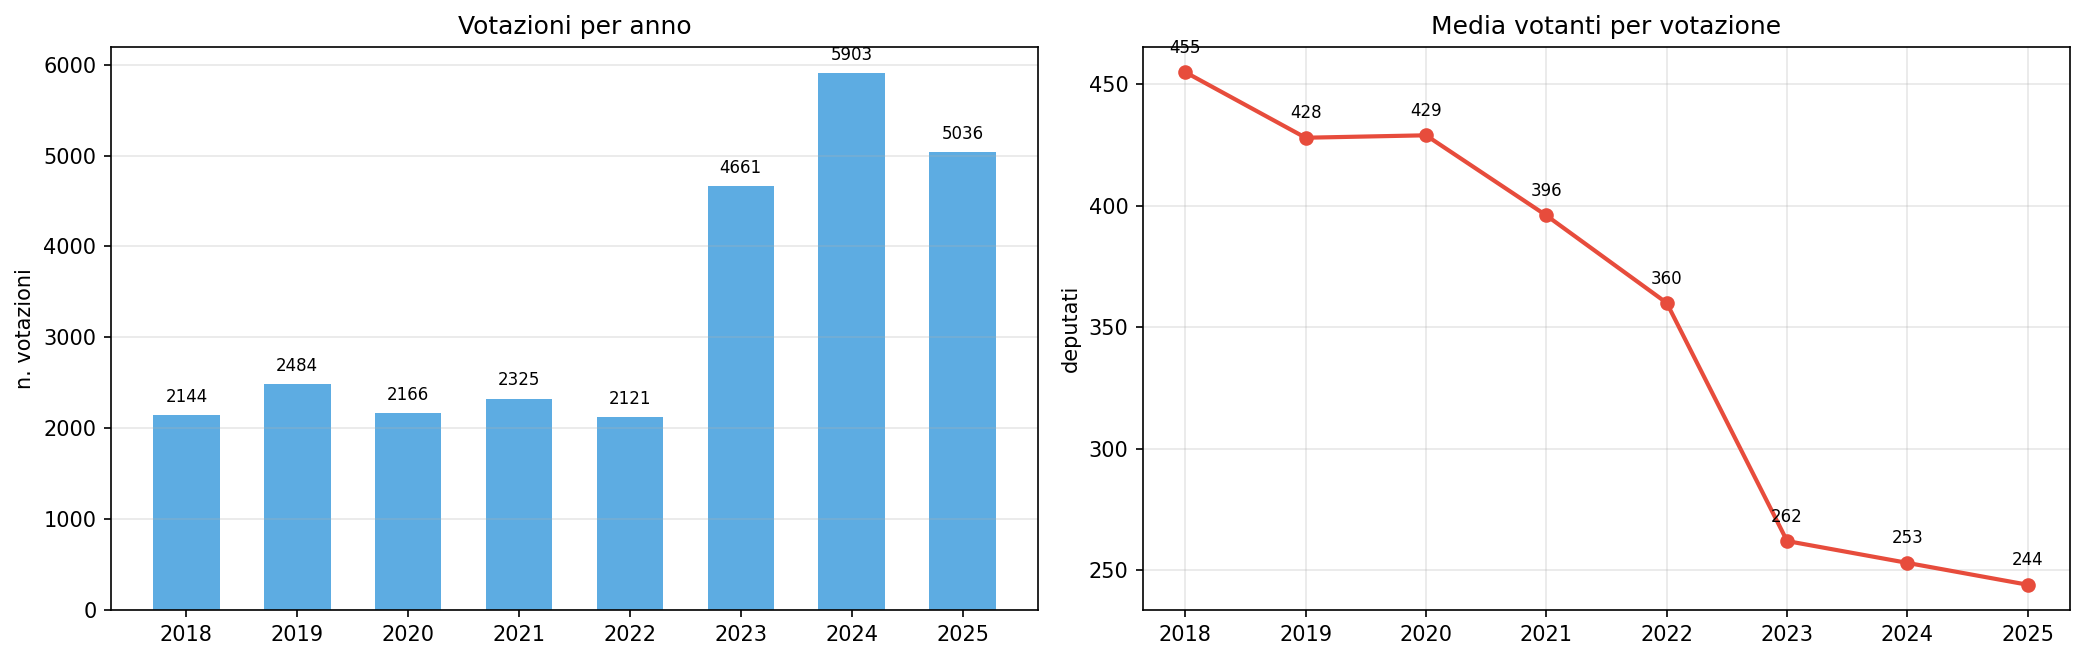

Salvato: figures/camera_trend.png


In [3]:
# Grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.bar(trend['anno'], trend['votazioni'], color='#3498db', alpha=0.8, width=0.6)
ax1.set_title('Votazioni per anno', fontsize=12)
ax1.set_ylabel('n. votazioni')
ax1.grid(alpha=0.3, axis='y')
for _, r in trend.iterrows():
    ax1.text(r['anno'], r['votazioni'] + 150, f"{int(r['votazioni'])}", ha='center', fontsize=8)

ax2.plot(trend['anno'], trend['media_votanti'], marker='o', linewidth=2, color='#e74c3c')
ax2.set_title('Media votanti per votazione', fontsize=12)
ax2.set_ylabel('deputati')
ax2.grid(alpha=0.3)
for _, r in trend.iterrows():
    ax2.text(r['anno'], r['media_votanti'] + 8, f"{int(r['media_votanti'])}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/camera_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/camera_trend.png')

In [4]:
# 2. Richieste di fiducia
fiducia = con.execute(f"""
    SELECT YEAR(data) as anno,
           COUNT(*) as totale,
           SUM(CASE WHEN richiesta_fiducia THEN 1 ELSE 0 END) as con_fiducia
    FROM read_parquet('{GCS}')
    GROUP BY 1 ORDER BY 1
""").fetchdf()
fiducia['pct_fiducia'] = (fiducia['con_fiducia'] * 100.0 / fiducia['totale']).round(1)
display(fiducia)

print(f"Richieste fiducia totali: {fiducia['con_fiducia'].sum()}")
print(f"Media per anno: {fiducia['con_fiducia'].mean():.0f}")

,anno,totale,con_fiducia,pct_fiducia
0,2018,2144,6.0,0.3
1,2019,2484,7.0,0.3
2,2020,2166,17.0,0.8
3,2021,2325,16.0,0.7
4,2022,2121,10.0,0.5
5,2023,4661,26.0,0.6
6,2024,5903,17.0,0.3
7,2025,5036,15.0,0.3


Richieste fiducia totali: 114.0
Media per anno: 14


In [5]:
# 3. Votazioni finali (leggi)
finali = con.execute(f"""
    SELECT YEAR(data) as anno,
           COUNT(*) as n,
           ROUND(AVG(favorevoli)) as media_fav,
           ROUND(AVG(contrari)) as media_cont,
           ROUND(SUM(CASE WHEN approvato THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_approvate,
    FROM read_parquet('{GCS}')
    WHERE votazione_finale = true
    GROUP BY 1 ORDER BY 1
""").fetchdf()
display(finali)
print(f"Leggi approvate (votazione finale): {finali['n'].sum()}")

,anno,n,media_fav,media_cont,pct_approvate
0,2018,37,374.0,53.0,100.0
1,2019,88,377.0,31.0,98.9
2,2020,67,347.0,62.0,100.0
3,2021,84,367.0,12.0,100.0
4,2022,56,326.0,27.0,100.0
5,2023,103,208.0,36.0,99.0
6,2024,95,179.0,48.0,100.0
7,2025,118,187.0,39.0,100.0


Leggi approvate (votazione finale): 648


In [6]:
# 4. Votazione segreta vs palese
segreta = con.execute(f"""
    SELECT YEAR(data) as anno,
           COUNT(*) as n,
           SUM(CASE WHEN votazione_segreta THEN 1 ELSE 0 END) as segrete,
           ROUND(SUM(CASE WHEN votazione_segreta THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as pct_segrete
    FROM read_parquet('{GCS}')
    GROUP BY 1 ORDER BY 1
""").fetchdf()
display(segreta)

,anno,n,segrete,pct_segrete
0,2018,2144,43.0,2.0
1,2019,2484,39.0,1.6
2,2020,2166,10.0,0.5
3,2021,2325,5.0,0.2
4,2022,2121,16.0,0.8
5,2023,4661,1.0,0.0
6,2024,5903,5.0,0.1
7,2025,5036,5.0,0.1


In [7]:
con.close()
print('Completato.')

Completato.
